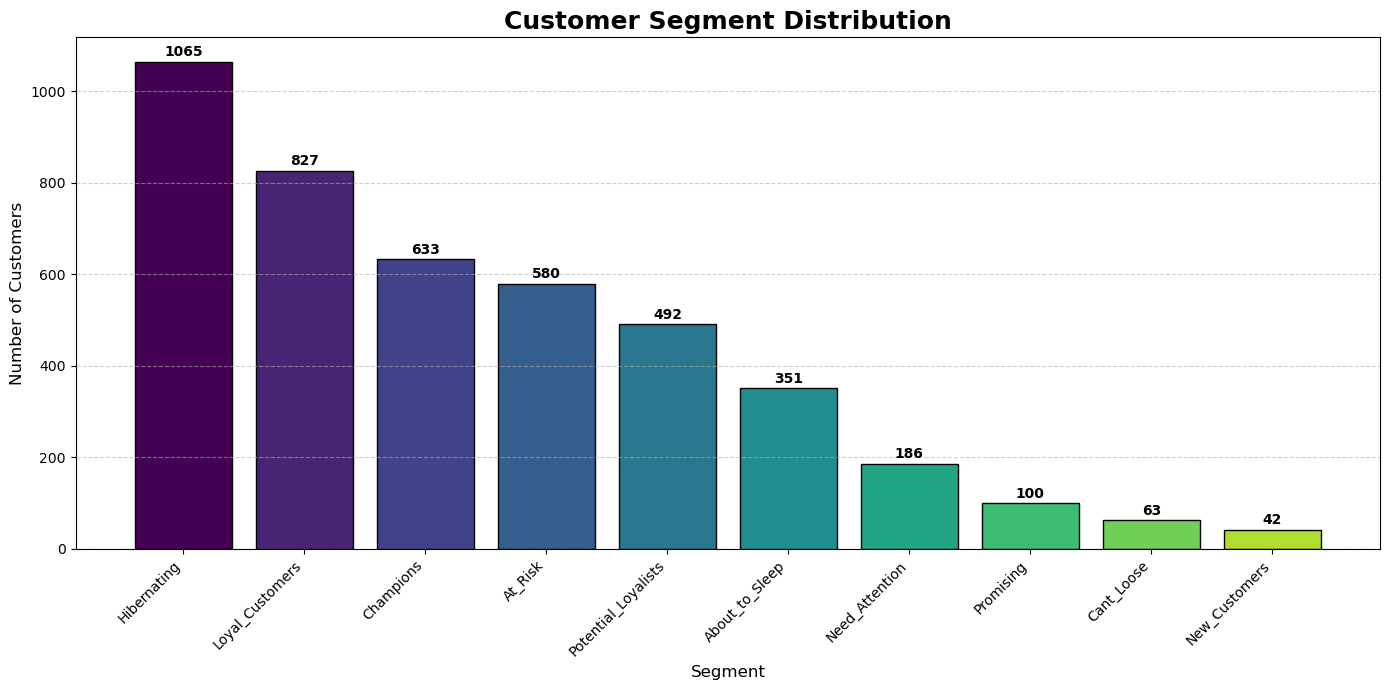

             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment  \
Customer_ID                                                                     
12346.0          326          1  77183.60       1       1       5          11   
12347.0            2          7   4310.00       5       5       5          55   
12348.0           75          4   1797.24       2       4       4          24   
12349.0           19          1   1757.55       4       1       4          41   
12350.0          310          1    334.40       1       1       2          11   

                 Segment  
Customer_ID               
12346.0      Hibernating  
12347.0        Champions  
12348.0          At_Risk  
12349.0        Promising  
12350.0      Hibernating  


In [8]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

# 1. DATA LOADING & SANITIZATION
# Using utf-8-sig to handle the Byte Order Mark (BOM) 'ï»¿'
df = pd.read_csv('online_retail.csv', sep=';', encoding='utf-8-sig')

# Standardize column names (strip spaces and rename for consistency)
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'InvoiceNo': 'Invoice_ID',
    'CustomerID': 'Customer_ID',
    'UnitPrice': 'Unit_Price',
    'InvoiceDate': 'Order_Date'
})

df['Order_Date'] = pd.to_datetime(df['Order_Date'],dayfirst=True)
df = df.dropna(subset=['Customer_ID'])
df = df[df['Quantity'] > 0]

# 2. FEATURE ENGINEERING
df['Line_Total'] = df['Quantity'] * df['Unit_Price']
latest_date = df['Order_Date'].max() + dt.timedelta(days=1)

# 3. RFM AGGREGATION
rfm = df.groupby('Customer_ID').agg({
    'Order_Date': lambda x: (latest_date - x.max()).days, # Recency
    'Invoice_ID': 'nunique',                             # Frequency
    'Line_Total': 'sum'                                  # Monetary
})

rfm.rename(columns={
    'Order_Date': 'Recency',
    'Invoice_ID': 'Frequency',
    'Line_Total': 'Monetary'
}, inplace=True)

# 4. QUANTILE SCORING (1-5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# 5. CUSTOMER SEGMENT MAPPING
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At_Risk',
    r'[1-2]5': 'Cant_Loose',
    r'3[1-2]': 'About_to_Sleep',
    r'33': 'Need_Attention',
    r'[3-4][4-5]': 'Loyal_Customers',
    r'41': 'Promising',
    r'51': 'New_Customers',
    r'[4-5][2-3]': 'Potential_Loyalists',
    r'5[4-5]': 'Champions'
}

rfm['Segment'] = rfm['RFM_Segment'].replace(seg_map, regex=True)

#  VISUALIZATION (Matplotlib)
segment_counts = rfm['Segment'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(14, 7))
bars = plt.bar(segment_counts.index, segment_counts.values, 
               color=plt.cm.viridis(range(0, 255, 255//len(segment_counts))),
               edgecolor='black')

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), 
             ha='center', va='bottom', fontweight='bold')

plt.title('Customer Segment Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(rfm.head())